In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, models, layers

In [11]:
!nvidia-smi

Tue Jun 23 17:18:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [14]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle datasets list

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                 Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          15846        368                1  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset    FIFA World Cup 2026 Player Performance Dataset         4154062  2026-06-10 12:58:47.093000           2659         59                1  
velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics  FIFA World Cup 2026 Complete Tournament Statistics      129266  2026-06-20 09:51:39.410000            473         30          

In [16]:
!kaggle datasets list -s "plant disease"

ref                                                         title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
vipoooool/new-plant-diseases-dataset                        New Plant Diseases Dataset                    2897709187  2018-11-18 07:09:16.050000         193403       1710  0.75             
turakut/plant-disease-classification                        Plant Disease Classification                      358274  2025-06-22 07:54:27.970000           2935         47  1                
rashikrahmanpritom/plant-disease-recognition-dataset        Plant disease recognition dataset             1339624018  2021-07-04 12:32:46.580000          30531        228  0.75             
sadmansakibmahi/plant-disease-expert              

In [17]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:09<00:00, 73.4MB/s]



In [18]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [19]:
import os
print(os.listdir())

['.config', 'kaggle.json', 'plantvillage', 'plantdisease.zip', 'PlantVillage', 'sample_data']


In [20]:
classes = os.listdir("PlantVillage")
print(len(classes))

15


In [21]:
print(classes[:5])

['Tomato_Early_blight', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Potato___Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite']


In [22]:
classes

['Tomato_Early_blight',
 'Potato___Late_blight',
 'Pepper__bell___Bacterial_spot',
 'Potato___Early_blight',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Target_Spot',
 'Tomato_Leaf_Mold',
 'Potato___healthy',
 'Tomato_Septoria_leaf_spot',
 'Tomato_healthy',
 'Tomato_Late_blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_Bacterial_spot',
 'Pepper__bell___healthy']

In [23]:
for ch in classes:
  print(ch, len(os.listdir(f"PlantVillage/{ch}")))

Tomato_Early_blight 1000
Potato___Late_blight 1000
Pepper__bell___Bacterial_spot 997
Potato___Early_blight 1000
Tomato_Spider_mites_Two_spotted_spider_mite 1676
Tomato__Tomato_mosaic_virus 373
Tomato__Target_Spot 1404
Tomato_Leaf_Mold 952
Potato___healthy 152
Tomato_Septoria_leaf_spot 1771
Tomato_healthy 1591
Tomato_Late_blight 1909
Tomato__Tomato_YellowLeaf__Curl_Virus 3209
Tomato_Bacterial_spot 2127
Pepper__bell___healthy 1478


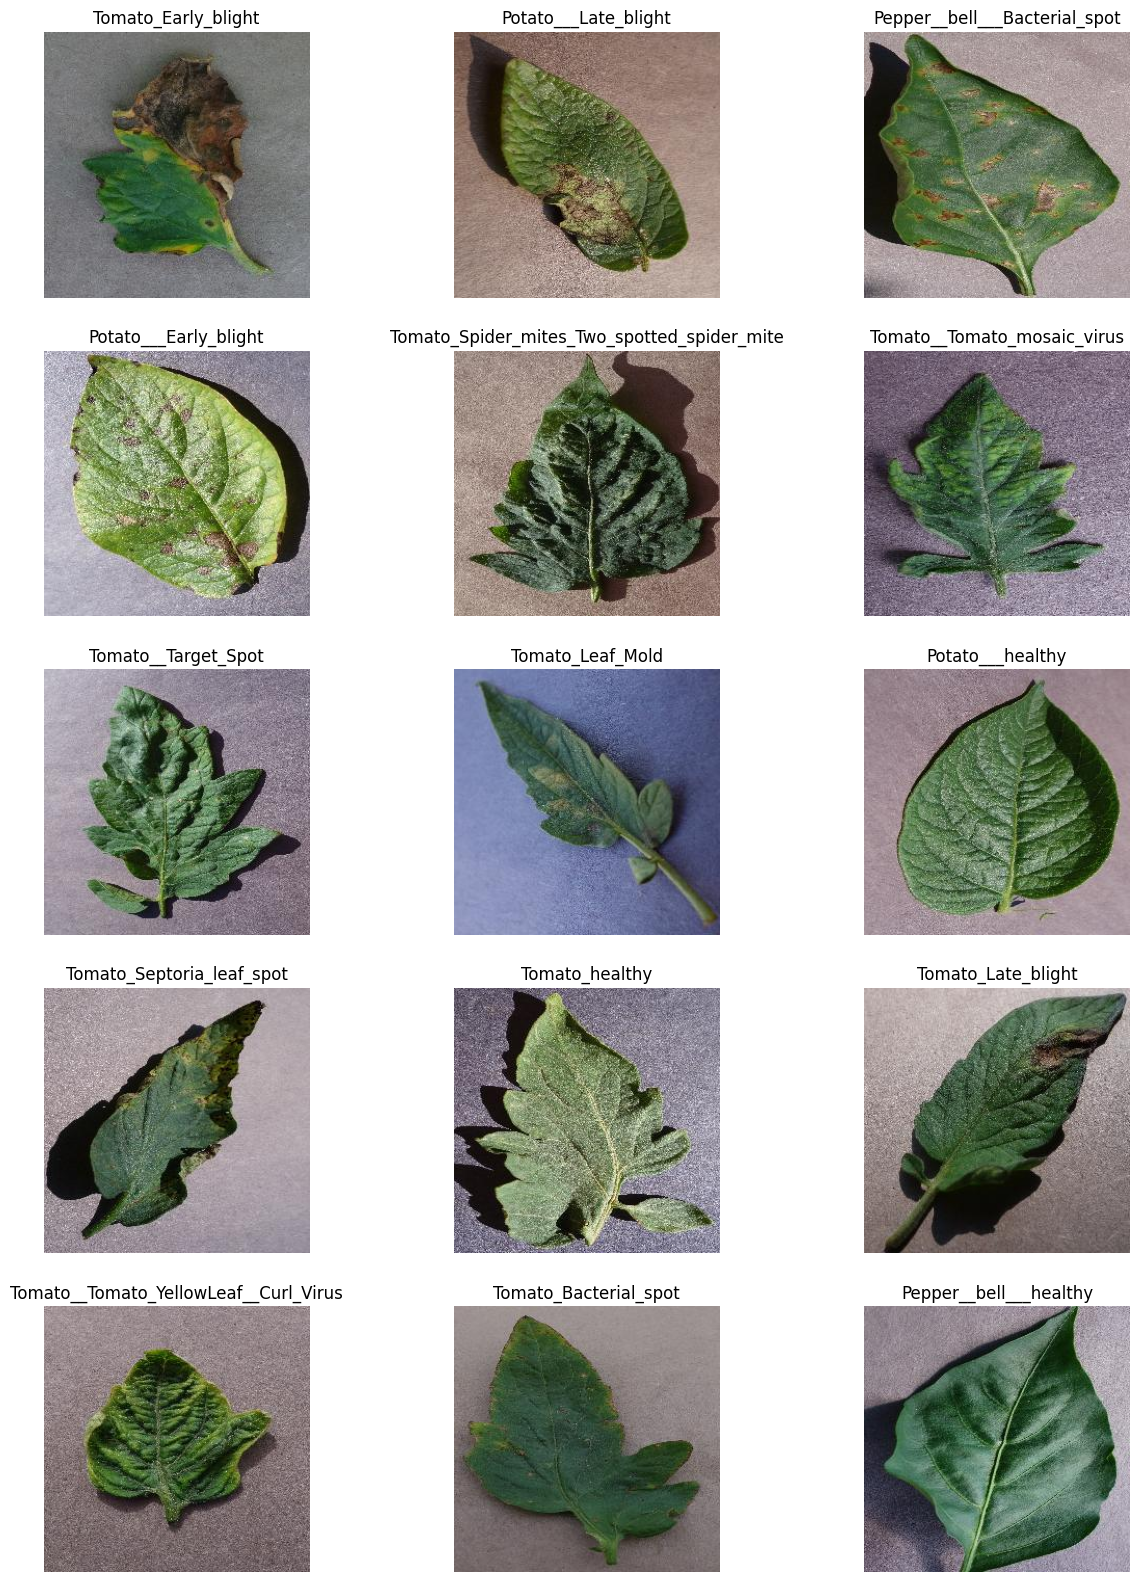

In [24]:
from PIL import Image

plt.figure(figsize = (15,20))

for i, cls in enumerate(classes):
  img_name = os.listdir(f"PlantVillage/{cls}")[0]
  img_path = f"PlantVillage/{cls}/{img_name}"

  img = Image.open(img_path)
  plt.subplot(5 ,3, i+1)
  plt.imshow(img)
  plt.title(cls)
  plt.axis("off")
plt.show()




In [25]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "PlantVillage",
    labels = "inferred",
    label_mode = 'int',
    image_size = (224, 224),
    batch_size= 32,
    seed = 42,
    validation_split = 0.2,
    subset = "training"
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "PlantVillage",
    labels = "inferred",
    label_mode = 'int',
    image_size = (224, 224),
    batch_size= 32,
    seed = 42,
    validation_split = 0.2,
    subset = "validation"
)


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [26]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(15, activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.7657 - loss: 0.7319 - val_accuracy: 0.8730 - val_loss: 0.3619
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.8711 - loss: 0.3878 - val_accuracy: 0.8985 - val_loss: 0.2982
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.8977 - loss: 0.3044 - val_accuracy: 0.9048 - val_loss: 0.2775
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9142 - loss: 0.2538 - val_accuracy: 0.9125 - val_loss: 0.2433
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9241 - loss: 0.2229 - val_accuracy: 0.9164 - val_loss: 0.2321
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9333 - loss: 0.1957 - val_accuracy: 0.9174 - val_loss: 0.2460
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.9395 - loss: 0.1764 - val_accuracy: 0.9283 - val_loss: 0.2097
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.9456 - loss: 0.1559 - 

In [28]:
y_true = []
y_pred = []

for images, labels in valid_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

In [29]:
print(y_true[20:30])
print(y_pred[20:30])

[np.int32(12), np.int32(10), np.int32(9), np.int32(8), np.int32(9), np.int32(8), np.int32(9), np.int32(2), np.int32(8), np.int32(11)]
[np.int64(12), np.int64(10), np.int64(9), np.int64(13), np.int64(9), np.int64(8), np.int64(9), np.int64(2), np.int64(10), np.int64(10)]


In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names = train_ds.class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.96      0.97       200
                     Pepper__bell___healthy       0.98      1.00      0.99       302
                      Potato___Early_blight       0.99      0.99      0.99       189
                       Potato___Late_blight       0.94      0.96      0.95       188
                           Potato___healthy       1.00      0.74      0.85        31
                      Tomato_Bacterial_spot       0.92      0.95      0.93       441
                        Tomato_Early_blight       0.78      0.77      0.77       191
                         Tomato_Late_blight       0.97      0.90      0.93       341
                           Tomato_Leaf_Mold       0.89      0.86      0.88       185
                  Tomato_Septoria_leaf_spot       0.86      0.91      0.88       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.89      0.95

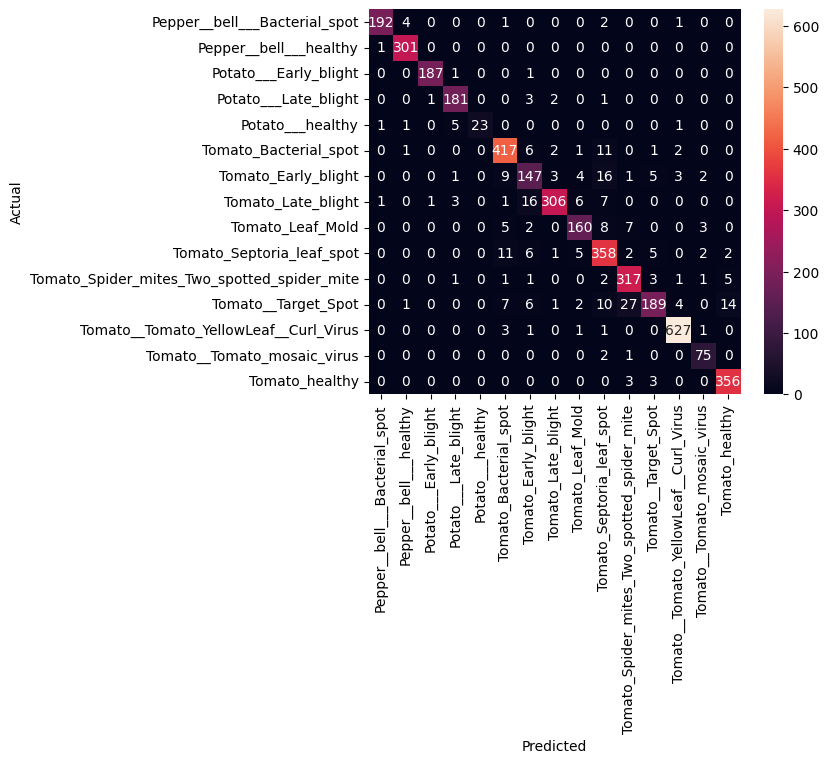

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=train_ds.class_names,

            yticklabels=train_ds.class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
model.save("plant_disease_mobilenet.h5")

In [33]:
from google.colab import files

files.download("plant_disease_mobilenet.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>